In [66]:
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import pandas as pd
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import time

In [68]:
categories = ["CB", "C0", "C1", "C2"]
category_dict = {"CB" : [" CВ", " CB", " СВ", " СB"], "C0" : [" CO", " C0", " С0", " СО", " CО", " СO"], "C1" : [" C1", " С1"], "C2" :[" C2", " С2"]}

In [70]:
urls = {"perek" : "https://www.perekrestok.ru/cat/search?search=яйца", "pyaterka" : "https://5ka.ru/search/?value=яйца"}
goods_classes = {"perek" : "product-card__content", "pyaterka" : "chakra-stack.KnkuqE3h-.HmedBAdm-.css-8g8ihq"}
shops_available = ['perek', 'pyaterka']
shop_name = {'perek': 'Перекресток', 'pyaterka' : 'Пятерочка'}

In [71]:
def get_category(name : str):
    for category in category_dict:
        for spelling in category_dict[category]:
            if spelling in name:
                return category
    return None

In [74]:
def get_goods(shop : str):
    driver = webdriver.Chrome()
    driver.get(urls[shop])
    time.sleep(5)
    actions = ActionChains(driver)
    actions.send_keys(Keys.END).perform()
    time.sleep(5)
    actions.send_keys(Keys.END).perform()
    goods = driver.find_elements(By.CLASS_NAME, goods_classes[shop])
    return goods

In [75]:
def get_name(good : str, shop : str):
    if shop == "pyaterka":
        return good.find_element(By.CLASS_NAME, "chakra-text.SdLEFc2B-.css-1jdqp4k").text
    if shop == "perek":
        return good.find_element(By.CLASS_NAME, "product-card__title").text
        

In [76]:
def get_price(good : str, shop : str):
    if shop == "pyaterka":
        price_rub = int(good.find_element(By.CLASS_NAME, "chakra-text.DUXYWqnZ-.css-6uvdux").text)
        price_kop = int(good.find_element(By.CLASS_NAME, "chakra-text.j2bifgeA-.css-6uvdux").text)
        price = price_rub + price_kop / 100
        
    if shop == "perek":
        price_raw = good.find_element(By.CLASS_NAME, "price-new")
        price = float(price_raw.text.split('\n')[1][:-2].replace(',', '.'))
    return price

In [77]:
def get_shop_egg_prices(shop : str):
    assert shop in shops_available, f"Магазин '{shop}' не поддерживается в данный момент. Пожалуйста, выберите магазин из списка {', '.join(map(str, shops_available))}"
    names = []
    prices = []
    eggs_data_dict = {'Название': [], 'Категория': [], 'Цена': []}
    
    goods = get_goods(shop)
    for good in goods:
        names.append(get_name(good, shop))
        prices.append(get_price(good, shop))
    raw_eggs_data_dict = dict(zip(names, prices))

    df = pd.DataFrame(eggs_data_dict)
    for name in raw_eggs_data_dict:
        category = get_category(name)
        if category:
            new_row = pd.DataFrame({"Название" : [name], "Категория" : [category], "Цена" : [raw_eggs_data_dict[name]]})
            df = pd.concat([df, new_row], ignore_index = True)
            
    df['Категория'] = pd.Categorical(df['Категория'], categories=categories, ordered=True)
    df['Количество яиц в упаковке'] = df['Название'].str.extract(r'(\d+)шт')
    df['Количество яиц в упаковке'] = pd.to_numeric(df['Количество яиц в упаковке'])
    df['Цена одного яйца'] = df['Цена'] / df['Количество яиц в упаковке']
    df = df.sort_values('Категория')
    df = df.reset_index(drop = True)
    df['Магазин'] = shop_name[shop]
    return df

In [78]:
df1 = get_shop_egg_prices("perek")
df2 = get_shop_egg_prices("pyaterka")

In [82]:
df = pd.concat([df1, df2], ignore_index = True)
df = df.sort_values('Категория')
df = df.reset_index(drop = True)
df

,Название,Категория,Цена,Количество яиц в упаковке,Цена одного яйца,Магазин
0,Яйцо куриное Окское мытое дезинфицированное СВ...,CB,159.99,10,15.999000,Перекресток
1,Яйцо Окское СВ столовое 10шт,CB,179.99,10,17.999000,Пятерочка
2,Яйцо куриное Село Зеленое Деревенское С0 10шт.,C0,144.99,10,14.499000,Пятерочка
3,Яйцо куриное Лето столовое СО 10шт.,C0,139.99,10,13.999000,Пятерочка
4,Яйца Село Зеленое Деревенские куриные СО 6шт,C0,99.99,6,16.665000,Пятерочка
5,Яйцо куриное Окское столовое СО 10шт.,C0,145.59,10,14.559000,Пятерочка
6,"Яйцо куриное Фёдоровская ПФ С0, 9шт",C0,199.99,9,22.221111,Перекресток
7,Яйцо куриное Роскар Экстра СО 10шт.,C0,139.99,10,13.999000,Пятерочка
8,Яйца Село Зелёное Деревенские куриные пищевые ...,C0,299.99,20,14.999500,Перекресток
9,"Яйцо куриное Лето пищевое столовое СО, 10шт",C0,139.99,10,13.999000,Перекресток


C:\Users\Yaroslav\AppData\Local\Temp\ipykernel_17104\584464100.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



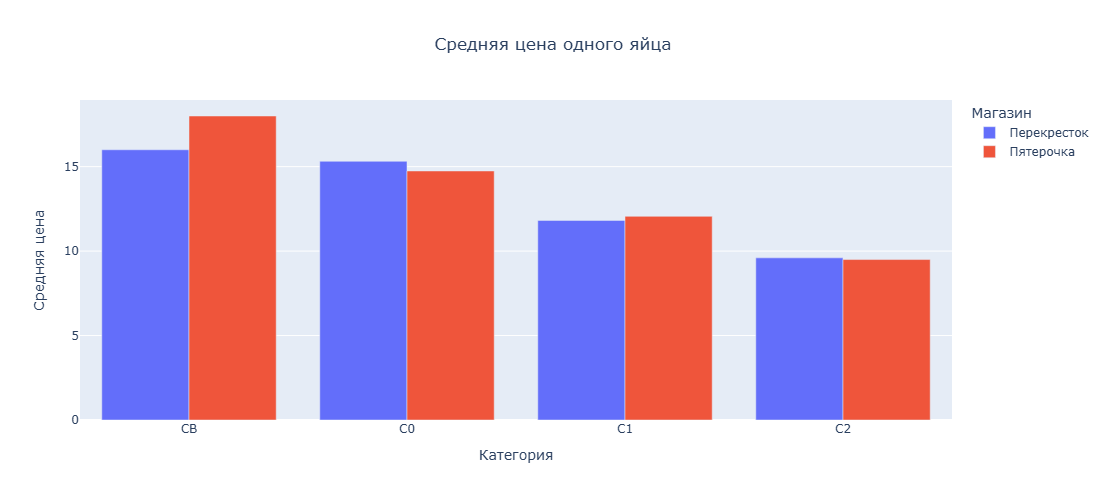

In [102]:
import plotly.express as px
df_grouped = df.groupby(["Категория", "Магазин"])["Цена одного яйца"].mean().reset_index()

fig = px.bar(df_grouped, x="Категория", y="Цена одного яйца", color="Магазин", 
             barmode="group",
             opacity = 1,
             title="Средняя цена одного яйца",
             labels={"Цена одного яйца": "Средняя цена", "Категория": "Категория"},
            width = 1000, height = 500)
fig.update_layout(title_x=0.5)
fig.show()